<a href="https://colab.research.google.com/github/Rabin-2468/Artificial-Intelligence-and-Machine-Learning/blob/main/2431876_RabindraSah_Insect_Image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part II: Image Classification with CNN — Insect Classification Dataset

<!-- This is the main title and introduction for the notebook. -->

This notebook is prepared for the **6CS012 Final Portfolio Part II: Vision Task**.

It assumes the insect dataset is already arranged in folders by class. No archive extraction is used in this notebook.

The notebook covers:

1. Dataset understanding, visualization, and cleaning  
2. Corrupted/unreadable image checking  
3. Class distribution and class imbalance checking    
4. Clean train/validation/test split  
5. Baseline CNN from scratch  
6. Deeper CNN with Batch Normalization, Dropout, and L2 regularization  
7. Adam vs SGD optimizer comparison  
8. Ablation study by removing Dropout  
9. Transfer learning using MobileNetV2  
10. Evaluation using accuracy, precision, recall, F1-score, confusion matrix, and sample predictions

## 0. Import Required Libraries

In [7]:
import os
import time
import hashlib
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Dataset Folder Path`


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
# Define the dataset folder path directly.
DATASET_ROOT = Path('/content/drive/MyDrive/AI ML/Assignment/Part2/Insect Classification')

if not DATASET_ROOT.exists():
    raise FileNotFoundError(f'Dataset folder not found: {DATASET_ROOT}')
if not DATASET_ROOT.is_dir():
    raise NotADirectoryError(f'The path is not a folder: {DATASET_ROOT}')

print('Dataset root:', DATASET_ROOT)

Dataset root: /content/drive/MyDrive/AI ML/Assignment/Part2/Insect Classification


## 2. Dataset Audit: Image Files, Corrupted Images, Duplicates, and Class Distribution

This section checks the real image folder directly. It checks:

- total image files,
- unreadable/corrupted image files,
- class names from folder names,
- class distribution,
- image size and color mode,


In [6]:
# Define valid image file extensions
VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}
# Define known folder names that might indicate data splits (e.g., train, test, val)
KNOWN_SPLIT_FOLDERS = {'train', 'test', 'val', 'valid', 'validation'}

def infer_label_and_split(path, root):
    """
    Infers the class label and dataset split (e.g., 'train', 'test') from an image file's path.
    Assumes folder structure like 'root/class_name/image.jpg' or 'root/split_name/class_name/image.jpg'.
    """
    # Get relative path parts to analyze folder structure
    rel_parts = path.relative_to(root).parts
    if len(rel_parts) < 2:
        # Not enough parts to infer label/split, return None label and 'all' split
        return None, 'all'
    first = rel_parts[0].lower()
    # Check if the first part is a known split folder
    if first in KNOWN_SPLIT_FOLDERS and len(rel_parts) >= 3:
        # If it's a split folder, use it and the next part as the label
        split_name = 'val' if first in {'val', 'valid', 'validation'} else first
        label = rel_parts[1]
    else:
        # Otherwise, assume no explicit split folder and the first part is the label
        split_name = 'all'
        label = rel_parts[0]
    return label, split_name

# Find all files in the dataset root, skipping hidden files
all_files = [p for p in DATASET_ROOT.rglob('*') if p.is_file() and not p.name.startswith('.')] # Skip hidden files
# Filter for image files based on defined extensions
image_files = [p for p in all_files if p.suffix.lower() in VALID_EXTENSIONS]
# Identify non-image files for reporting
non_image_files = [p for p in all_files if p.suffix.lower() not in VALID_EXTENSIONS]

# Print initial statistics about the file types found
print('Total files found:', len(all_files))
print('Image files found:', len(image_files))
print('Non-image files found:', len(non_image_files))
# Display a sample of non-image files if any exist
if non_image_files[:10]:
    print('Sample non-image files:', [str(p.relative_to(DATASET_ROOT)) for p in non_image_files[:10]])

# Lists to store records of readable images and problematic (bad) images
records = []
bad_images = []

# Iterate through each identified image file to audit its properties
for p in image_files:
    # Infer label and split using the helper function
    label, split_name = infer_label_and_split(p, DATASET_ROOT)
    try:
        # Attempt to open and verify the image file
        with Image.open(p) as img:
            img.verify() # Verify if it's a valid image
        # Re-open the image to extract its properties safely
        with Image.open(p) as img:
            width, height = img.size
            mode = img.mode

        # Append details of readable images to the records list
        records.append({
            'path': str(p),
            'relative_path': str(p.relative_to(DATASET_ROOT)),
            'label': label,
            'original_split': split_name,
            'extension': p.suffix.lower(),
            'width': width,
            'height': height,
            'mode': mode,
            'size_bytes': p.stat().st_size,

        })
    except Exception as e:
        # If an error occurs (e.g., corrupted image), record its details
        bad_images.append({
            'path': str(p),
            'relative_path': str(p.relative_to(DATASET_ROOT)),
            'label': label,
            'original_split': split_name,
            'error': repr(e),
            'size_bytes': p.stat().st_size
        })

# Convert the lists of records into Pandas DataFrames for easier analysis
df_all = pd.DataFrame(records)
df_bad = pd.DataFrame(bad_images)

# Print summary of readable vs. unreadable images
print('\nReadable images:', len(df_all))
print('Unreadable/corrupted images:', len(df_bad))

# Display the head of the DataFrame for bad images if any were found
if len(df_bad) > 0:
    display(df_bad.head(10))

# Raise an error if no readable image files are found, preventing further processing issues
if len(df_all) == 0:
    raise ValueError('No readable image files found. Please check the dataset folder path and class folders.')

# Calculate and display class counts
class_counts = df_all['label'].value_counts().sort_index()
class_distribution = class_counts.reset_index()
class_distribution.columns = ['class_name', 'image_count']
display(class_distribution)

# Calculate and report class imbalance ratio
imbalance_ratio = class_counts.max() / class_counts.min()
print(f'Class imbalance ratio (max/min): {imbalance_ratio:.2f}')
# Provide an observation based on the imbalance ratio
if imbalance_ratio >= 2:
    print('Observation: The dataset has noticeable class imbalance. Class weights will be used during training.')
else:
    print('Observation: The dataset is reasonably balanced, but class weights will still be calculated for safety.')

# Display distribution of image extensions
print('\nImage extensions:')
display(df_all['extension'].value_counts().rename_axis('extension').reset_index(name='count'))

# Display distribution of image color modes
print('\nImage color modes:')
display(df_all['mode'].value_counts().rename_axis('mode').reset_index(name='count'))

# Display summary statistics for image dimensions and sizes
print('\nImage size summary:')
display(df_all[['width', 'height', 'size_bytes']].describe())


Total files found: 2632
Image files found: 2632
Non-image files found: 0

Readable images: 2510
Unreadable/corrupted images: 122


,path,relative_path,label,original_split,error,size_bytes
0,/content/drive/MyDrive/AI ML/Assignment/Part2/...,train/stem_borer/jpg_27 - Copy (2).jpg,stem_borer,train,"UnidentifiedImageError(""cannot identify image ...",10
1,/content/drive/MyDrive/AI ML/Assignment/Part2/...,train/stem_borer/jpg_9 - Copy (2).jpg,stem_borer,train,"UnidentifiedImageError(""cannot identify image ...",10
2,/content/drive/MyDrive/AI ML/Assignment/Part2/...,train/stem_borer/jpg_49 - Copy.jpg,stem_borer,train,"UnidentifiedImageError(""cannot identify image ...",10
3,/content/drive/MyDrive/AI ML/Assignment/Part2/...,train/stem_borer/jpg_1.jpg,stem_borer,train,"UnidentifiedImageError(""cannot identify image ...",10
4,/content/drive/MyDrive/AI ML/Assignment/Part2/...,train/stem_borer/jpg_65 - Copy (2) - Copy.jpg,stem_borer,train,"UnidentifiedImageError(""cannot identify image ...",10
5,/content/drive/MyDrive/AI ML/Assignment/Part2/...,train/stem_borer/jpg_0 - Copy.jpg,stem_borer,train,"UnidentifiedImageError(""cannot identify image ...",10
6,/content/drive/MyDrive/AI ML/Assignment/Part2/...,train/stem_borer/jpg_99.jpg,stem_borer,train,"UnidentifiedImageError(""cannot identify image ...",10
7,/content/drive/MyDrive/AI ML/Assignment/Part2/...,train/stem_borer/jpg_27 - Copy.jpg,stem_borer,train,"UnidentifiedImageError(""cannot identify image ...",10
8,/content/drive/MyDrive/AI ML/Assignment/Part2/...,train/stem_borer/jpg_11.jpg,stem_borer,train,"UnidentifiedImageError(""cannot identify image ...",10
9,/content/drive/MyDrive/AI ML/Assignment/Part2/...,train/stem_borer/jpg_65 - Copy (2).jpg,stem_borer,train,"UnidentifiedImageError(""cannot identify image ...",10


,class_name,image_count
0,aphids,298
1,armyworm,259
2,beetle,327
3,bollworm,267
4,grasshopper,310
5,mites,282
6,mosquito,340
7,sawfly,223
8,stem_borer,204


Class imbalance ratio (max/min): 1.67
Observation: The dataset is reasonably balanced, but class weights will still be calculated for safety.

Image extensions:


,extension,count
0,.jpg,2510



Image color modes:


,mode,count
0,RGB,2496
1,RGBA,10
2,P,4



Image size summary:


,width,height,size_bytes
count,2510.000000,2510.000000,2.510000e+03
mean,363.107570,256.635857,2.523652e+04
std,296.867898,219.224492,1.208333e+05
min,180.000000,121.000000,2.726000e+03
25%,251.000000,177.000000,6.084000e+03
50%,275.000000,191.000000,7.713000e+03
75%,300.000000,225.000000,1.078500e+04
max,2500.000000,3088.000000,2.483810e+06



Duplicate image detection was skipped as requested.


## 3. Visualize Class Distribution and Sample Images

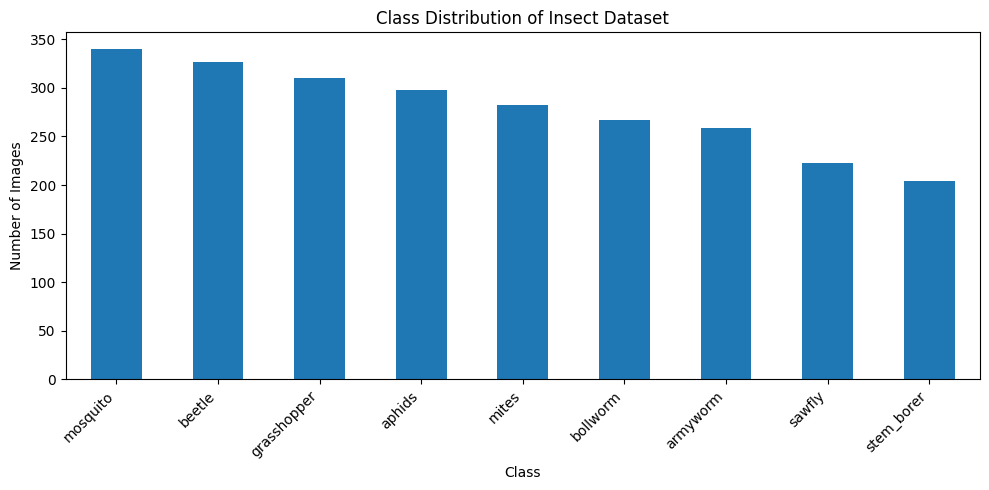

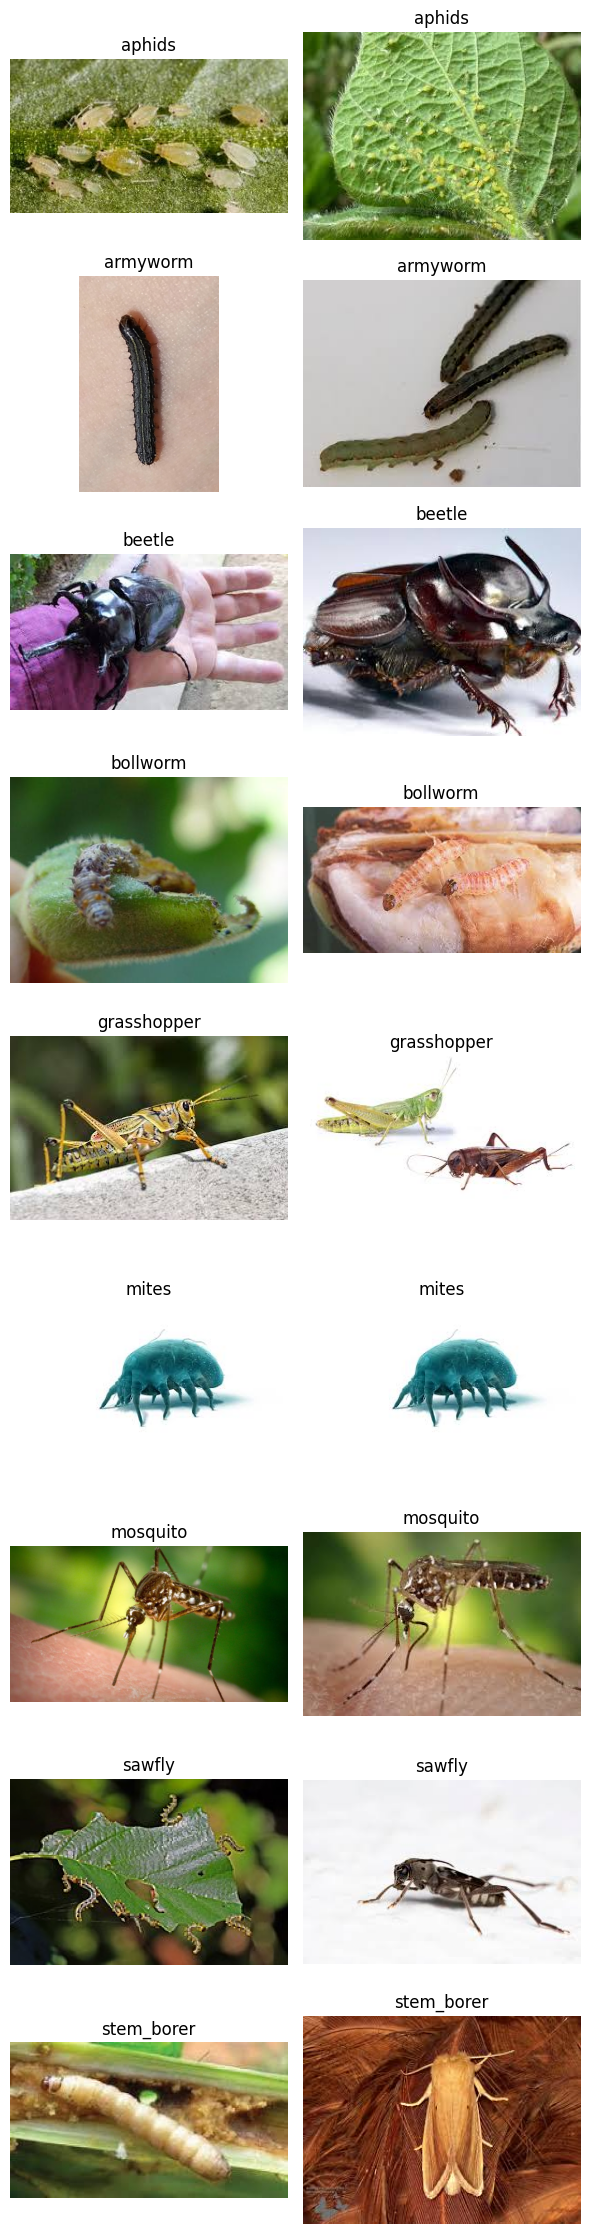

In [10]:
# Plot the distribution of classes in the dataset.
plt.figure(figsize=(10, 5))
class_counts.sort_values(ascending=False).plot(kind='bar')
plt.title('Class Distribution of Insect Dataset')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

def show_sample_images(df, n_per_class=2):
    """
    Displays a specified number of sample images for each class.

    Args:
        df (pd.DataFrame): DataFrame containing image paths and labels.
        n_per_class (int): Number of sample images to display per class.
    """
    # Get unique class labels and sort them for consistent display
    classes = sorted(df['label'].dropna().unique())
    sample_rows = []
    # Select a random sample of images for each class
    for cls in classes:
        sample_rows.extend(df[df['label'] == cls].sample(min(n_per_class, (df['label'] == cls).sum()), random_state=SEED).to_dict('records'))

    # Determine the layout for the subplot grid
    cols = n_per_class
    rows = len(classes)
    plt.figure(figsize=(cols * 3, rows * 2.5))
    # Iterate through the selected samples and display each image
    for i, row in enumerate(sample_rows):
        img = Image.open(row['path']).convert('RGB') # Load image and convert to RGB
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(row['label']) # Set title to the image's class label
        plt.axis('off') # Hide axes for cleaner image display
    plt.tight_layout()
    plt.show()

# Call the function to display sample images from the entire dataset
show_sample_images(df_all, n_per_class=2)

## 4. Cleaning Decision and Clean Split

The notebook removes unreadable images and keeps only one copy from each exact duplicate group. Then it creates a clean stratified split:

- 70% training
- 15% validation
- 15% testing

A clean split is used so that the same copied image does not appear in both training and testing.


In [11]:
# As requested, duplicate image removal has been skipped.
# Proceeding with all readable images identified in the dataset audit.
df_clean = df_all.copy()

print('Duplicate image removal has been skipped as requested.')
print('Proceeding with all readable images:', len(df_clean))
# The following lines are commented out as they are no longer relevant due to skipping duplicate removal:
# print('Readable images before duplicate removal:', len(df_all))
# print('Images after exact duplicate removal:', len(df_clean))
# print('Removed duplicate copies:', len(df_all) - len(df_clean))

# Remove very small classes if any class has fewer than 3 images, because stratified train/val/test needs enough samples.
min_required = 3
class_counts_clean = df_clean['label'].value_counts()
small_classes = class_counts_clean[class_counts_clean < min_required].index.tolist()
if small_classes:
    print('Classes removed because they have too few images:', small_classes)
    df_clean = df_clean[~df_clean['label'].isin(small_classes)].copy().reset_index(drop=True)
else:
    print('No classes with fewer than 3 images were found, or duplicate removal was skipped.')

train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.30,
    stratify=df_clean['label'],
    random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print('Train images:', len(train_df))
print('Validation images:', len(val_df))
print('Test images:', len(test_df))

split_summary = pd.DataFrame({
    'train': train_df['label'].value_counts().sort_index(),
    'validation': val_df['label'].value_counts().sort_index(),
    'test': test_df['label'].value_counts().sort_index()
}).fillna(0).astype(int)
display(split_summary)

class_names = sorted(df_clean['label'].unique())
num_classes = len(class_names)
class_to_index = {name: i for i, name in enumerate(class_names)}
index_to_class = {i: name for name, i in class_to_index.items()}

print('Number of classes:', num_classes)
print('Class names:', class_names)

Duplicate image removal has been skipped as requested.
Proceeding with all readable images: 2510
No classes with fewer than 3 images were found, or duplicate removal was skipped.
Train images: 1757
Validation images: 376
Test images: 377


,train,validation,test
label,,,
aphids,209,44,45
armyworm,181,39,39
beetle,229,49,49
bollworm,187,40,40
grasshopper,217,46,47
mites,197,42,43
mosquito,238,51,51
sawfly,156,34,33
stem_borer,143,31,30


Number of classes: 9
Class names: ['aphids', 'armyworm', 'beetle', 'bollworm', 'grasshopper', 'mites', 'mosquito', 'sawfly', 'stem_borer']


## 5. Create TensorFlow Datasets and Apply Preprocessing

Preprocessing applied:

- load image from folder path,
- decode as RGB,
- resize to 224 × 224 pixels,
- normalize pixel values from 0–255 to 0–1,
- one-hot encode labels.

Data augmentation is applied only to training data.


In [12]:
# Define image dimensions and batch size for TensorFlow datasets.
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
# AUTOTUNE allows TensorFlow to dynamically tune the number of parallel calls for data processing.
AUTOTUNE = tf.data.AUTOTUNE

def make_tf_dataset(df, shuffle=False, augment=False):
    """
    Creates a TensorFlow dataset from a Pandas DataFrame containing image paths and labels.

    Args:
        df (pd.DataFrame): DataFrame with 'path' and 'label' columns.
        shuffle (bool): Whether to shuffle the dataset.
        augment (bool): Whether to apply data augmentation.

    Returns:
        tf.data.Dataset: A TensorFlow dataset ready for model training.
    """
    # Extract image paths and map labels to numerical indices.
    paths = df['path'].values
    labels = df['label'].map(class_to_index).values.astype(np.int32)

    # Create a TensorFlow dataset from slices of paths and labels.
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    # Apply shuffling if requested, with a buffer for better randomness.
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)

    def load_image(path, label):
        """
        Loads, decodes, resizes, normalizes an image, and one-hot encodes its label.
        """
        image = tf.io.read_file(path) # Read the image file.
        image = tf.image.decode_image(image, channels=3, expand_animations=False) # Decode to RGB.
        image.set_shape([None, None, 3]) # Set shape for resizing.
        image = tf.image.resize(image, IMG_SIZE) # Resize images to a consistent size.
        image = tf.cast(image, tf.float32) / 255.0 # Normalize pixel values to [0, 1].
        label = tf.one_hot(label, depth=num_classes) # One-hot encode the labels.
        return image, label

    # Apply the image loading and preprocessing function to the dataset.
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    # Apply data augmentation if requested (only for training data).
    if augment:
        # Define a sequential model for data augmentation layers.
        data_augmentation = keras.Sequential([
            layers.RandomFlip('horizontal'), # Randomly flip images horizontally.
            layers.RandomRotation(0.08),    # Randomly rotate images.
            layers.RandomZoom(0.10),        # Randomly zoom into images.
            layers.RandomContrast(0.10),    # Randomly adjust image contrast.
        ], name='data_augmentation')

        def apply_augmentation(image, label):
            # Apply augmentation only during training.
            return data_augmentation(image, training=True), label

        # Map the augmentation function to the dataset.
        ds = ds.map(apply_augmentation, num_parallel_calls=AUTOTUNE)

    # Batch the dataset and prefetch elements for performance optimization.
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

# Create TensorFlow datasets for training, validation, and testing.
# Training dataset includes shuffling and augmentation.
train_ds = make_tf_dataset(train_df, shuffle=True, augment=True)
# Validation and test datasets do not include shuffling or augmentation.
val_ds = make_tf_dataset(val_df, shuffle=False, augment=False)
test_ds = make_tf_dataset(test_df, shuffle=False, augment=False)

# Class weights to reduce bias toward larger classes during training, especially with imbalanced datasets.
# These weights are calculated based on the training dataset's label distribution.
train_label_indices = train_df['label'].map(class_to_index).values
weights = compute_class_weight(class_weight='balanced', classes=np.arange(num_classes), y=train_label_indices)
class_weight = {i: float(w) for i, w in enumerate(weights)}
print('Class weights:', class_weight)

Class weights: {0: 0.9340776182881446, 1: 1.0785758133824432, 2: 0.8524987869966036, 3: 1.043969102792632, 4: 0.899641577060932, 5: 0.990975747320925, 6: 0.8202614379084967, 7: 1.2514245014245013, 8: 1.3651903651903652}


## 6. Visualize Augmented Training Images

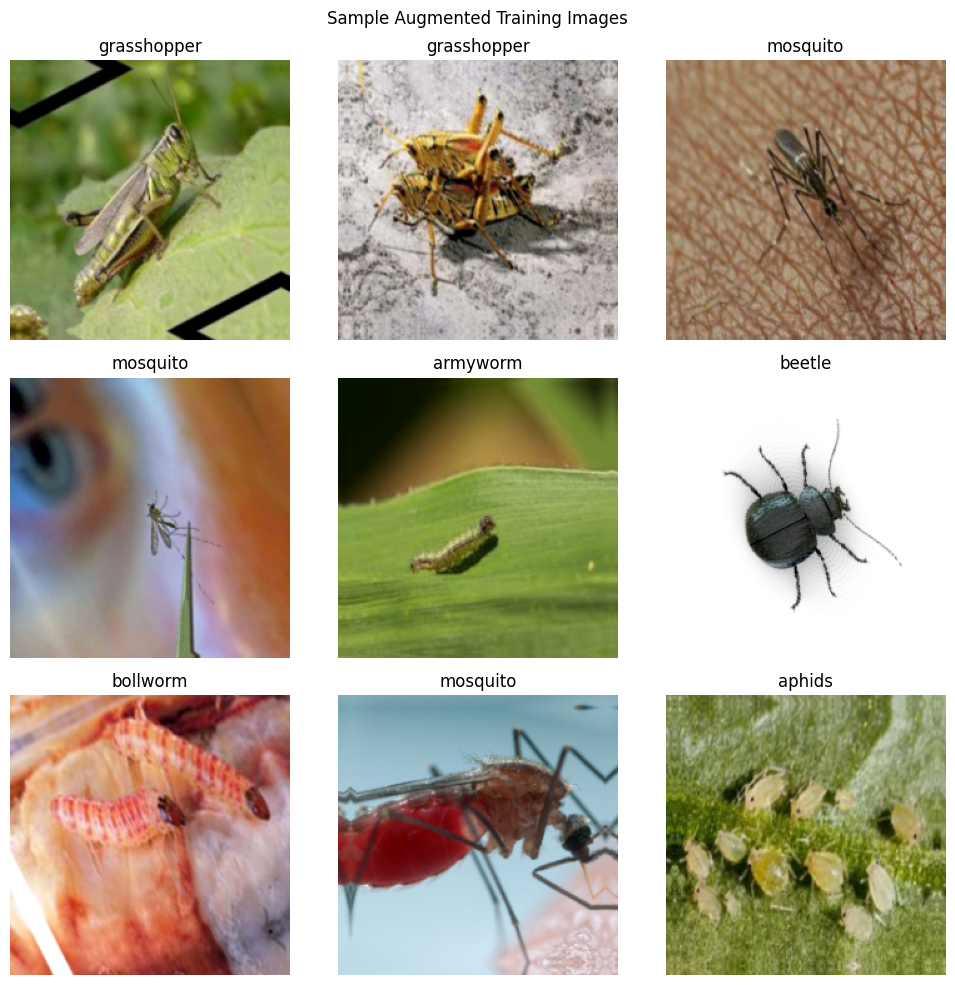

In [13]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(min(9, images.shape[0])):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(index_to_class[int(tf.argmax(labels[i]).numpy())])
        plt.axis('off')
plt.suptitle('Sample Augmented Training Images')
plt.tight_layout()
plt.show()

## 7. Helper Functions for Training and Evaluation

In [14]:
callbacks_common = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6)
]

## 8. Part A — Baseline CNN from Scratch

The baseline CNN follows the assignment requirement:

- Three convolutional layers
- Each convolutional layer followed by max-pooling
- Three fully connected layers
- Softmax output layer for multi-class classification


In [15]:
def build_baseline_cnn(input_shape=(224, 224, 3), num_classes=num_classes):
    """
    Constructs and compiles a baseline Convolutional Neural Network (CNN) model.

    Args:
        input_shape (tuple): The shape of the input images (height, width, channels).
        num_classes (int): The number of output classes for classification.

    Returns:
        keras.Model: The compiled Keras Sequential model.
    """
    model = keras.Sequential([
        # Input layer specifying the shape of the images (e.g., 224x224 pixels with 3 color channels).
        layers.Input(shape=input_shape),

        # First convolutional block:
        # Conv2D layer with 32 filters, 3x3 kernel, ReLU activation, and 'same' padding to preserve dimensions.
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        # MaxPooling2D layer to reduce spatial dimensions, using a 2x2 pool size.
        layers.MaxPooling2D((2, 2)),

        # Second convolutional block:
        # Conv2D layer with 64 filters, 3x3 kernel, ReLU activation, and 'same' padding.
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        # MaxPooling2D layer to further reduce spatial dimensions.
        layers.MaxPooling2D((2, 2)),

        # Third convolutional block:
        # Conv2D layer with 128 filters, 3x3 kernel, ReLU activation, and 'same' padding.
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        # MaxPooling2D layer for spatial dimension reduction.
        layers.MaxPooling2D((2, 2)),

        # Flatten layer to convert the 3D output of convolutional layers into a 1D vector
        # for feeding into fully connected (Dense) layers.
        layers.Flatten(),
        # First Dense (fully connected) layer with 256 units and ReLU activation.
        layers.Dense(256, activation='relu'),
        # Second Dense layer with 128 units and ReLU activation.
        layers.Dense(128, activation='relu'),
        # Third Dense layer with 64 units and ReLU activation.
        layers.Dense(64, activation='relu'),
        # Output Dense layer with 'num_classes' units and 'softmax' activation for multi-class classification.
        # Softmax outputs probabilities for each class, summing to 1.
        layers.Dense(num_classes, activation='softmax')
    ], name='baseline_cnn')

    # Compile the model:
    # Using Adam optimizer with a learning rate of 1e-3.
    # 'categorical_crossentropy' as the loss function for multi-class classification with one-hot encoded labels.
    # 'accuracy' as the metric to monitor during training.
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Instantiate and build the baseline CNN model.
baseline_model = build_baseline_cnn()
# Display a summary of the model's architecture, including layer names, output shapes, and number of parameters.
baseline_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,825,353 (98.52 MB)

 Trainable params: 25,825,353 (98.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 30s 549ms/step - accuracy: 0.9784 - loss: 0.0765 - val_accuracy: 0.9920 - val_loss: 0.0924 - learning_rate: 3.0000e-04
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 30s 547ms/step - accuracy: 0.9863 - loss: 0.0431 - val_accuracy: 0.9920 - val_loss: 0.0943 - learning_rate: 3.0000e-04
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 42s 574ms/step - accuracy: 0.9892 - loss: 0.0394 - val_accuracy: 0.9894 - val_loss: 0.1056 - learning_rate: 3.0000e-04
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 33s 596ms/step - accuracy: 0.9972 - loss: 0.0216 - val_accuracy: 0.9947 - val_loss: 0.0915 - learning_rate: 9.0000e-05
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 30s 553ms/step - accuracy: 0.9972 - loss: 0.0189 - val_accuracy: 0.9947 - val_loss: 0.0850 - learning_rate: 9.0000e-05
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 29s 535ms/step - accuracy: 0.9949 - loss: 0.0194 - val_accuracy: 0.9947 - val_loss: 0.0867 - learning_rate: 9.0000e-05
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 31s 572ms/step - acc

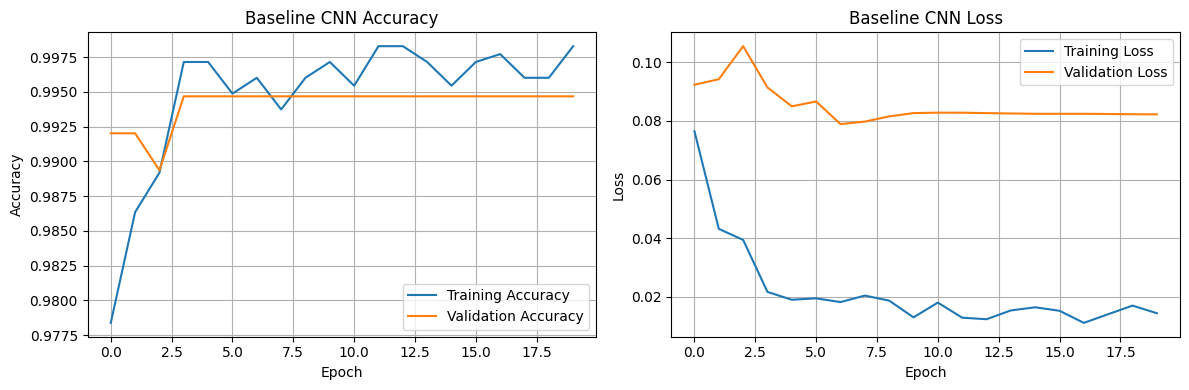


Evaluating Baseline CNN on test set...
Baseline CNN Test Loss: 0.1786
Baseline CNN Test Accuracy: 0.9867

Classification Report:
              precision    recall  f1-score   support

      aphids       1.00      1.00      1.00        45
    armyworm       1.00      0.97      0.99        39
      beetle       1.00      0.98      0.99        49
    bollworm       1.00      0.93      0.96        40
 grasshopper       0.98      1.00      0.99        47
       mites       0.98      1.00      0.99        43
    mosquito       1.00      1.00      1.00        51
      sawfly       0.92      1.00      0.96        33
  stem_borer       1.00      1.00      1.00        30

    accuracy                           0.99       377
   macro avg       0.99      0.99      0.99       377
weighted avg       0.99      0.99      0.99       377



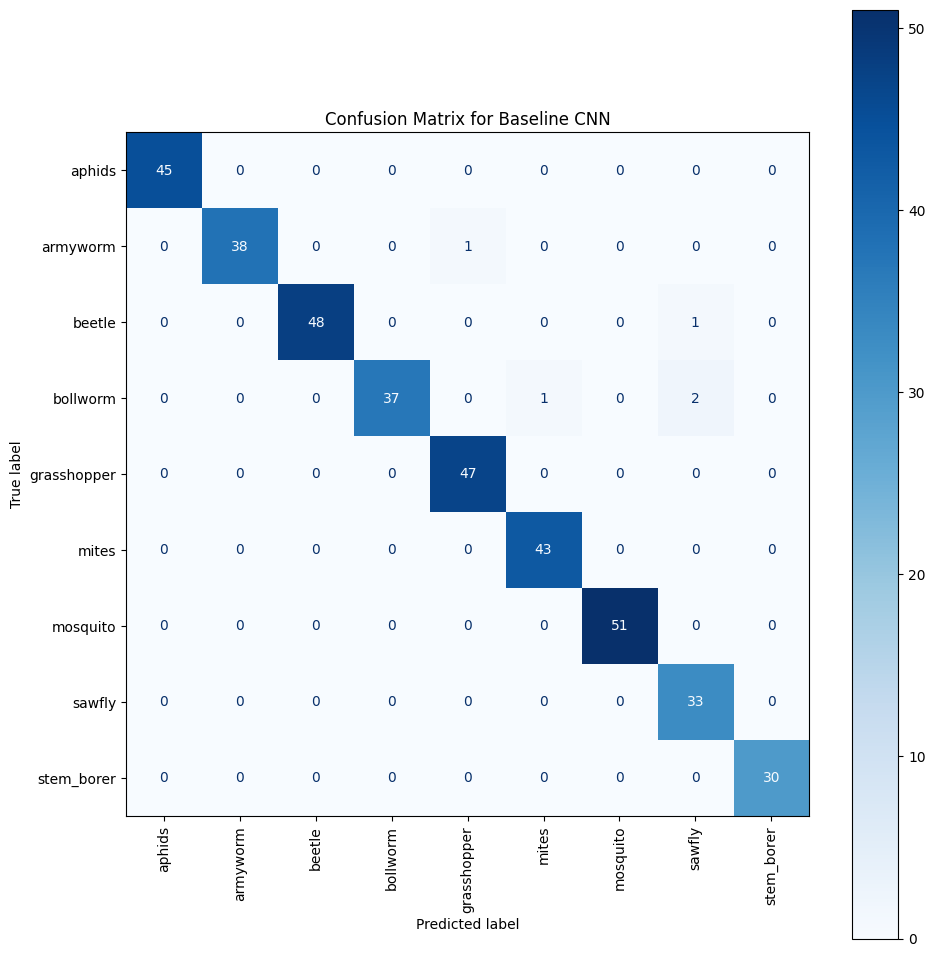

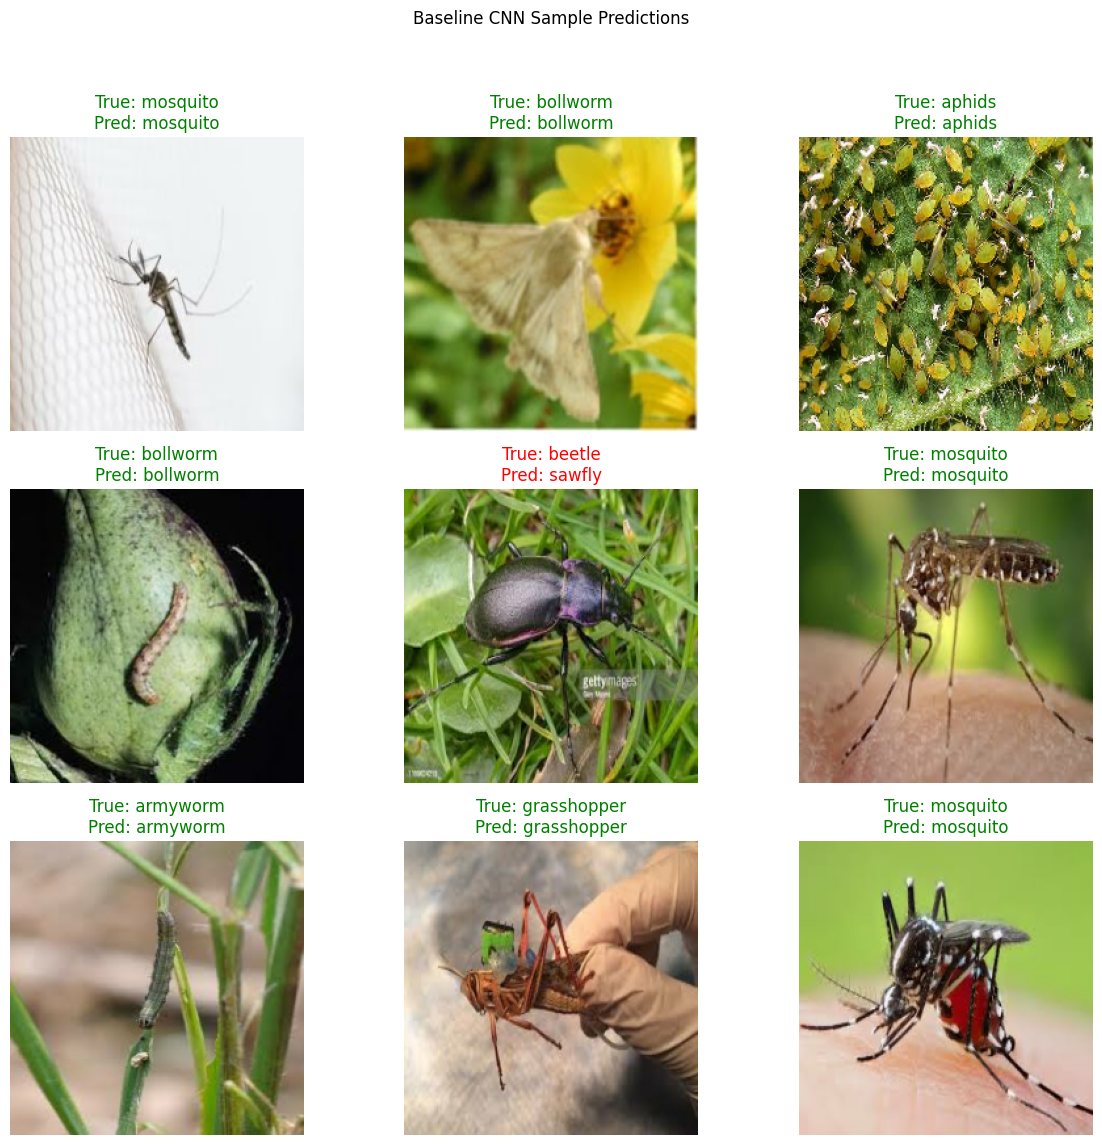

In [17]:
def plot_history(history, model_name):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def evaluate_model(model, test_dataset, model_name):
    print(f'\nEvaluating {model_name} on test set...')
    loss, accuracy = model.evaluate(test_dataset, verbose=0)
    print(f'{model_name} Test Loss: {loss:.4f}')
    print(f'{model_name} Test Accuracy: {accuracy:.4f}')

    y_true = []
    y_pred_probs = []
    for images, labels in test_dataset:
        y_true.extend(tf.argmax(labels, axis=1).numpy())
        y_pred_probs.extend(model.predict(images, verbose=0))

    y_pred = np.argmax(y_pred_probs, axis=1)

    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    metrics = {
        'model': model_name,
        'accuracy': accuracy,
        'precision_weighted': report['weighted avg']['precision'],
        'recall_weighted': report['weighted avg']['recall'],
        'f1_weighted': report['weighted avg']['f1-score'],
    }

    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    return metrics, np.array(y_true), np.array(y_pred), np.array(y_pred_probs)

def show_predictions(model, df, n=9, title='Sample Predictions'):
    plt.figure(figsize=(12, 12))
    sample_df = df.sample(n=n, random_state=SEED).reset_index(drop=True)

    # Prepare images for prediction
    images_to_predict = []
    original_labels = []
    for idx, row in sample_df.iterrows():
        img_path = row['path']
        img = tf.io.read_file(img_path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32) / 255.0 # For baseline CNN
        images_to_predict.append(img)
        original_labels.append(row['label'])

    images_to_predict = tf.stack(images_to_predict)
    predictions = model.predict(images_to_predict, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    for i in range(n):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images_to_predict[i].numpy())
        true_label = original_labels[i]
        predicted_label = index_to_class[predicted_classes[i]]
        color = 'green' if true_label == predicted_label else 'red'
        plt.title(f'True: {true_label}\nPred: {predicted_label}', color=color)
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
    plt.show()

EPOCHS_BASELINE = 20

start_time = time.time()
history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_BASELINE,
    callbacks=callbacks_common,
    class_weight=class_weight,
    verbose=1
)
baseline_time = time.time() - start_time
print(f'Baseline CNN training time: {baseline_time:.2f} seconds')

plot_history(history_baseline, 'Baseline CNN')
baseline_metrics, baseline_y_true, baseline_y_pred, baseline_y_prob = evaluate_model(baseline_model, test_ds, 'Baseline CNN')
baseline_metrics['training_time_seconds'] = baseline_time
show_predictions(baseline_model, test_df, n=9, title='Baseline CNN Sample Predictions')

## 9. Deeper CNN with Regularization

This model has at least double the convolutional layers compared with the baseline model. It uses:

- More convolutional layers and filters
- Batch Normalization
- Dropout
- L2 regularization
- Global Average Pooling to reduce parameter count


In [18]:
def build_deeper_cnn(input_shape=(224, 224, 3), num_classes=num_classes, optimizer_name='adam', use_dropout=True):
    """
    Constructs and compiles a deeper Convolutional Neural Network (CNN) model
    with Batch Normalization, Dropout, and L2 regularization.

    Args:
        input_shape (tuple): The shape of the input images (height, width, channels).
        num_classes (int): The number of output classes for classification.
        optimizer_name (str): The name of the optimizer to use ('adam' or 'sgd').
        use_dropout (bool): Whether to include Dropout layers in the model.

    Returns:
        keras.Model: The compiled Keras Model.
    """
    reg = regularizers.l2(1e-4)
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=reg)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    if use_dropout:
        x = layers.Dropout(0.20)(x)

    x = layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    if use_dropout:
        x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    if use_dropout:
        x = layers.Dropout(0.30)(x)

    x = layers.Conv2D(256, (3, 3), padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation='relu', kernel_regularizer=reg)(x)
    if use_dropout:
        x = layers.Dropout(0.40)(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=reg)(x)
    if use_dropout:
        x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name=f'deeper_cnn_{optimizer_name}_dropout_{use_dropout}')

    if optimizer_name.lower() == 'sgd':
        optimizer = keras.optimizers.SGD(learning_rate=1e-2, momentum=0.9)
    else:
        optimizer = keras.optimizers.Adam(learning_rate=1e-3)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

deeper_adam_model = build_deeper_cnn(optimizer_name='adam', use_dropout=True)
deeper_adam_model.summary()

Model: "deeper_cnn_adam_dropout_True"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 684,841 (2.61 MB)

 Trainable params: 683,433 (2.61 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.1884 - loss: 2.2638 - val_accuracy: 0.1144 - val_loss: 2.2985 - learning_rate: 0.0010
Epoch 2/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 33s 606ms/step - accuracy: 0.2396 - loss: 2.1586 - val_accuracy: 0.1170 - val_loss: 2.3573 - learning_rate: 0.0010
Epoch 3/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 34s 624ms/step - accuracy: 0.2618 - loss: 2.0952 - val_accuracy: 0.1011 - val_loss: 2.5554 - learning_rate: 3.0000e-04
Epoch 4/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 34s 608ms/step - accuracy: 0.3108 - loss: 2.0306 - val_accuracy: 0.1090 - val_loss: 2.4240 - learning_rate: 3.0000e-04
Epoch 5/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 34s 609ms/step - accuracy: 0.3244 - loss: 1.9841 - val_accuracy: 0.1064 - val_loss: 2.7422 - learning_rate: 9.0000e-05
Epoch 6/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 35s 633ms/step - accuracy: 0.3290 - loss: 1.9606 - val_accuracy: 0.0931 - val_loss: 2.7865 - learning_rate: 9.0000e-05
Epoch 7/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 34s 608ms/step - accuracy: 0.33

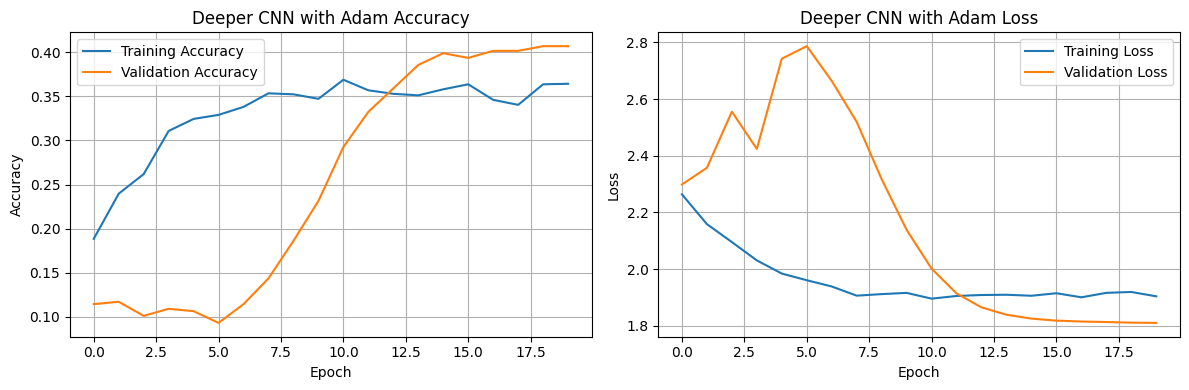


Evaluating Deeper CNN with Adam on test set...
Deeper CNN with Adam Test Loss: 2.2773
Deeper CNN with Adam Test Accuracy: 0.1379


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


Classification Report:
              precision    recall  f1-score   support

      aphids       0.00      0.00      0.00        45
    armyworm       0.11      0.74      0.19        39
      beetle       0.00      0.00      0.00        49
    bollworm       0.00      0.00      0.00        40
 grasshopper       0.00      0.00      0.00        47
       mites       0.18      0.40      0.25        43
    mosquito       0.43      0.12      0.18        51
      sawfly       0.00      0.00      0.00        33
  stem_borer       0.00      0.00      0.00        30

    accuracy                           0.14       377
   macro avg       0.08      0.14      0.07       377
weighted avg       0.09      0.14      0.07       377



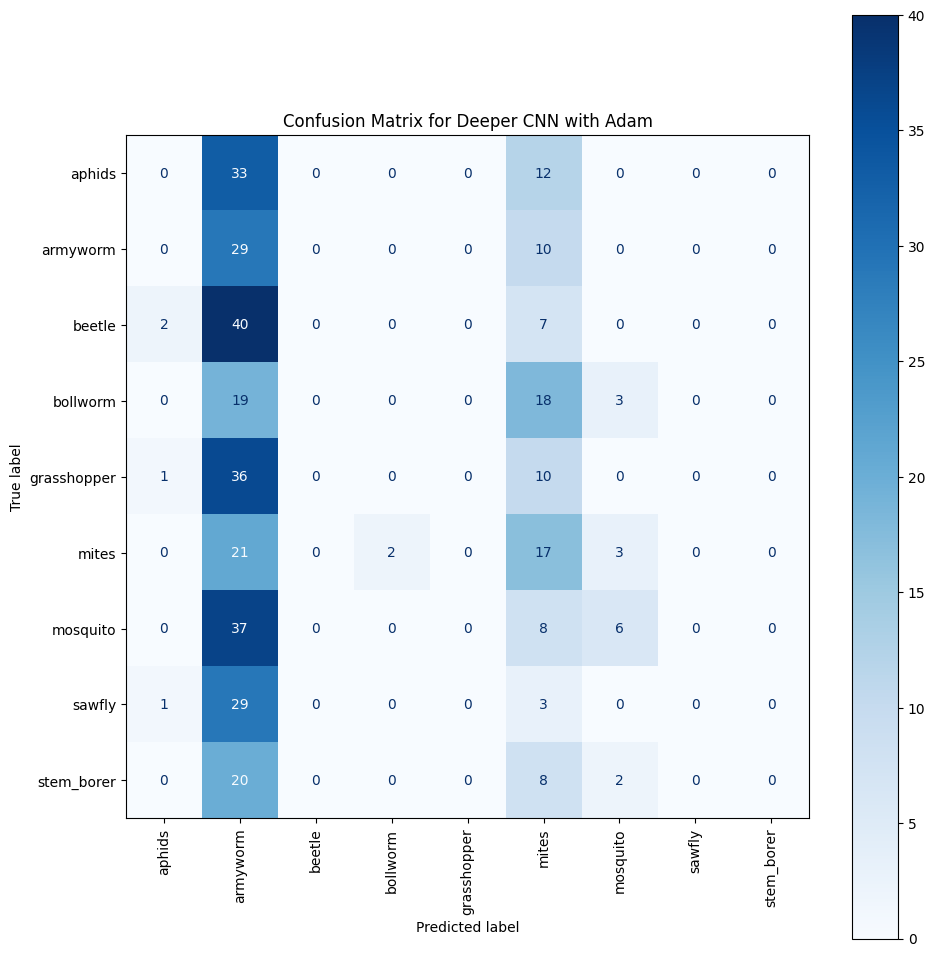

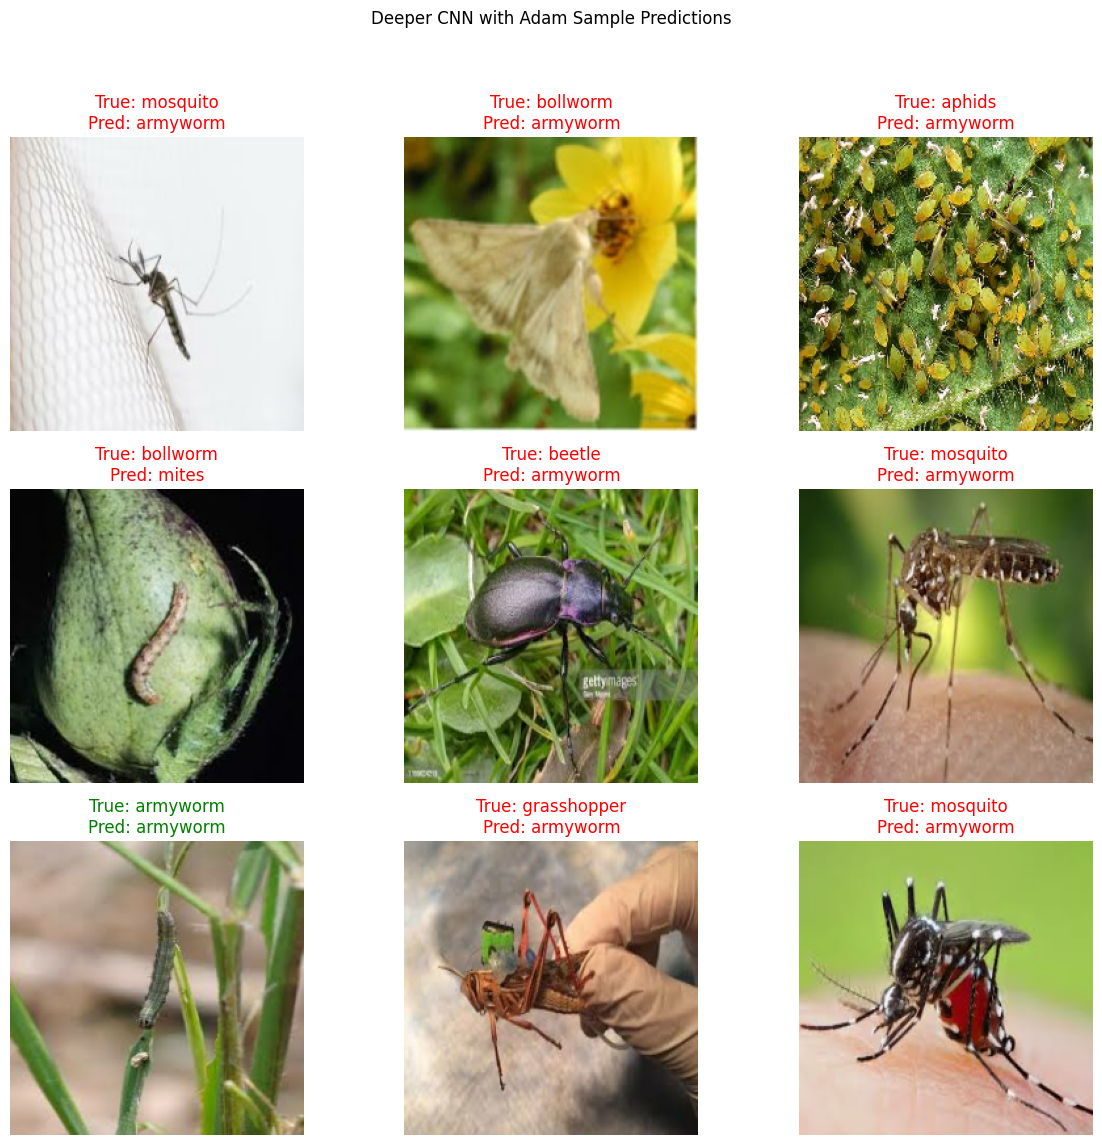

In [19]:
EPOCHS_DEEPER = 25

start_time = time.time()
history_deeper_adam = deeper_adam_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_DEEPER,
    callbacks=callbacks_common,
    class_weight=class_weight,
    verbose=1
)
deeper_adam_time = time.time() - start_time
print(f'Deeper CNN with Adam training time: {deeper_adam_time:.2f} seconds')

plot_history(history_deeper_adam, 'Deeper CNN with Adam')
deeper_adam_metrics, deeper_adam_y_true, deeper_adam_y_pred, deeper_adam_y_prob = evaluate_model(deeper_adam_model, test_ds, 'Deeper CNN with Adam')
deeper_adam_metrics['training_time_seconds'] = deeper_adam_time
show_predictions(deeper_adam_model, test_df, n=9, title='Deeper CNN with Adam Sample Predictions')

## 10. Optimizer Analysis: SGD vs Adam

The assignment asks to train the deeper model with SGD and Adam and compare convergence and final performance.


Model: "deeper_cnn_sgd_dropout_True"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 684,841 (2.61 MB)

 Trainable params: 683,433 (2.61 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 63s 851ms/step - accuracy: 0.1633 - loss: 2.2793 - val_accuracy: 0.1170 - val_loss: 2.3488 - learning_rate: 0.0100
Epoch 2/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 56s 603ms/step - accuracy: 0.2379 - loss: 2.1583 - val_accuracy: 0.1170 - val_loss: 2.4448 - learning_rate: 0.0100
Epoch 3/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 35s 635ms/step - accuracy: 0.2777 - loss: 2.1112 - val_accuracy: 0.1170 - val_loss: 2.5118 - learning_rate: 0.0030
Epoch 4/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 34s 614ms/step - accuracy: 0.2960 - loss: 2.0633 - val_accuracy: 0.1516 - val_loss: 2.5194 - learning_rate: 0.0030
Epoch 5/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 34s 616ms/step - accuracy: 0.3017 - loss: 2.0440 - val_accuracy: 0.1516 - val_loss: 2.4703 - learning_rate: 9.0000e-04
Epoch 6/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 35s 639ms/step - accuracy: 0.3193 - loss: 2.0153 - val_accuracy: 0.1649 - val_loss: 2.4337 - learning_rate: 9.0000e-04
Epoch 7/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 33s 603ms/step - accuracy: 0.3238 - 

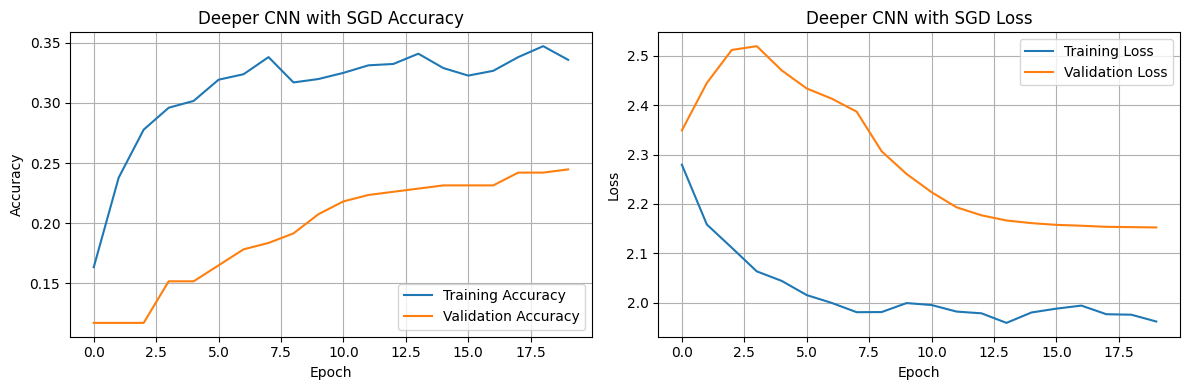


Evaluating Deeper CNN with SGD on test set...
Deeper CNN with SGD Test Loss: 2.3456
Deeper CNN with SGD Test Accuracy: 0.1194


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


Classification Report:
              precision    recall  f1-score   support

      aphids       0.12      1.00      0.21        45
    armyworm       0.00      0.00      0.00        39
      beetle       0.00      0.00      0.00        49
    bollworm       0.00      0.00      0.00        40
 grasshopper       0.00      0.00      0.00        47
       mites       0.00      0.00      0.00        43
    mosquito       0.00      0.00      0.00        51
      sawfly       0.00      0.00      0.00        33
  stem_borer       0.00      0.00      0.00        30

    accuracy                           0.12       377
   macro avg       0.01      0.11      0.02       377
weighted avg       0.01      0.12      0.03       377



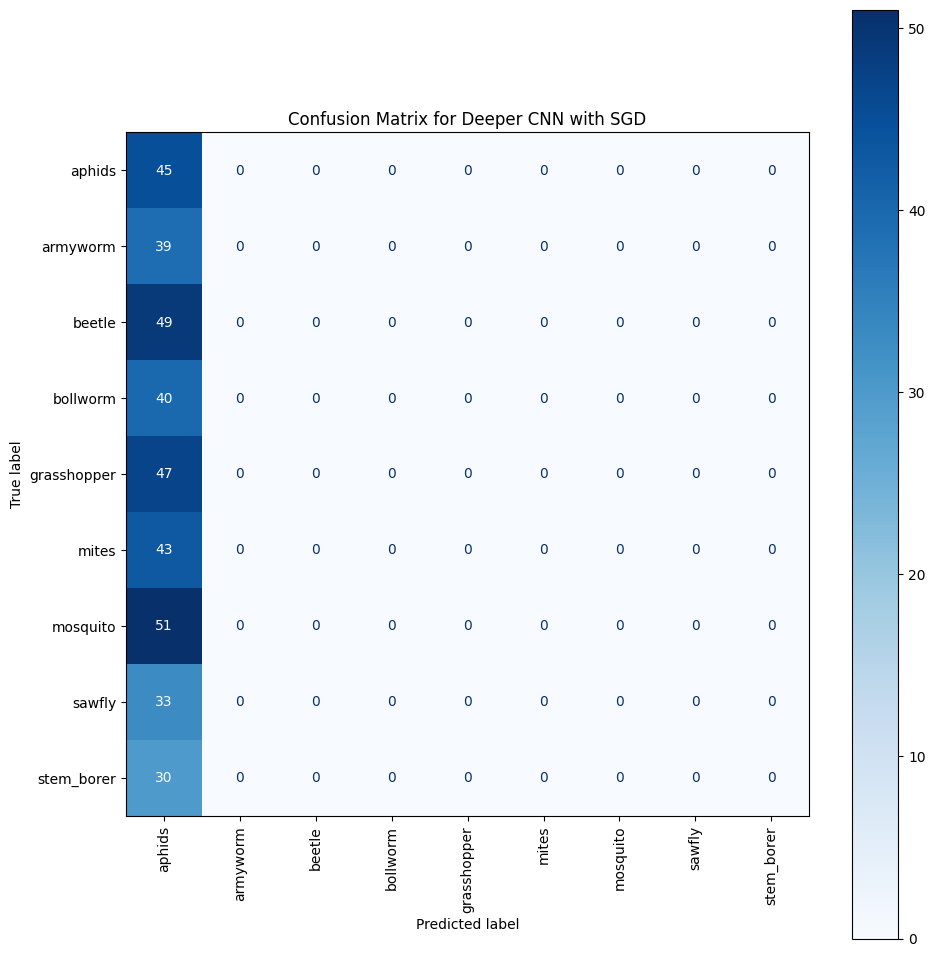

In [20]:
deeper_sgd_model = build_deeper_cnn(optimizer_name='sgd', use_dropout=True)
deeper_sgd_model.summary()

start_time = time.time()
history_deeper_sgd = deeper_sgd_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_DEEPER,
    callbacks=callbacks_common,
    class_weight=class_weight,
    verbose=1
)
deeper_sgd_time = time.time() - start_time
print(f'Deeper CNN with SGD training time: {deeper_sgd_time:.2f} seconds')

plot_history(history_deeper_sgd, 'Deeper CNN with SGD')
deeper_sgd_metrics, deeper_sgd_y_true, deeper_sgd_y_pred, deeper_sgd_y_prob = evaluate_model(deeper_sgd_model, test_ds, 'Deeper CNN with SGD')
deeper_sgd_metrics['training_time_seconds'] = deeper_sgd_time

## 11. Ablation Study: Deeper CNN without Dropout

This experiment removes Dropout from the deeper model to check how regularization affects performance.


Model: "deeper_cnn_adam_dropout_False"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 28, 28, 128)    │             

 Total params: 684,841 (2.61 MB)

 Trainable params: 683,433 (2.61 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 50s 693ms/step - accuracy: 0.2982 - loss: 1.9892 - val_accuracy: 0.1064 - val_loss: 2.2051 - learning_rate: 1.0000e-04
Epoch 2/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 33s 599ms/step - accuracy: 0.3842 - loss: 1.7841 - val_accuracy: 0.1037 - val_loss: 2.2880 - learning_rate: 1.0000e-04
Epoch 3/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 34s 624ms/step - accuracy: 0.4337 - loss: 1.6596 - val_accuracy: 0.0957 - val_loss: 2.4047 - learning_rate: 3.0000e-05
Epoch 4/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 34s 618ms/step - accuracy: 0.4764 - loss: 1.5829 - val_accuracy: 0.0931 - val_loss: 2.5785 - learning_rate: 3.0000e-05
Epoch 5/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 32s 583ms/step - accuracy: 0.4781 - loss: 1.5615 - val_accuracy: 0.0931 - val_loss: 2.6595 - learning_rate: 9.0000e-06
Epoch 6/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 35s 629ms/step - accuracy: 0.4986 - loss: 1.5467 - val_accuracy: 0.0851 - val_loss: 2.6257 - learning_rate: 9.0000e-06
Epoch 7/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 39s 587ms/step - acc

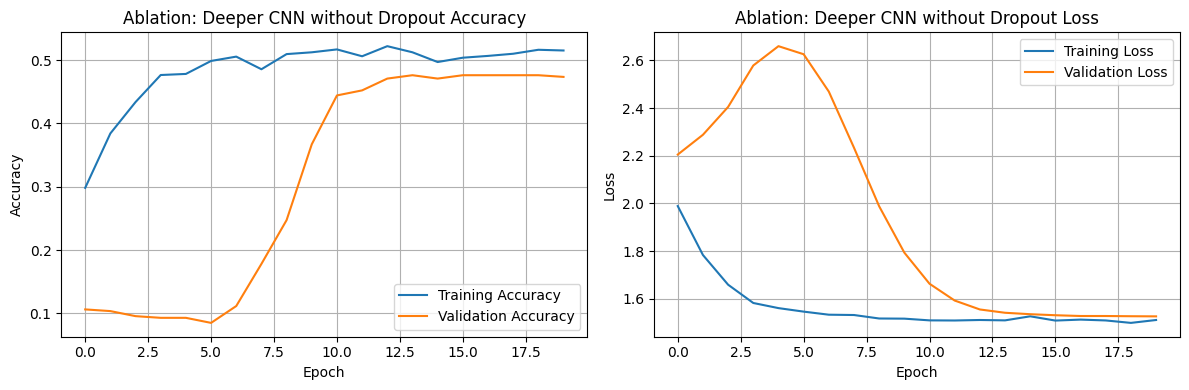


Evaluating Ablation: Deeper CNN without Dropout on test set...
Ablation: Deeper CNN without Dropout Test Loss: 2.2037
Ablation: Deeper CNN without Dropout Test Accuracy: 0.1114


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


Classification Report:
              precision    recall  f1-score   support

      aphids       0.00      0.00      0.00        45
    armyworm       0.11      1.00      0.19        39
      beetle       0.00      0.00      0.00        49
    bollworm       0.00      0.00      0.00        40
 grasshopper       0.00      0.00      0.00        47
       mites       0.00      0.00      0.00        43
    mosquito       0.30      0.06      0.10        51
      sawfly       0.00      0.00      0.00        33
  stem_borer       0.00      0.00      0.00        30

    accuracy                           0.11       377
   macro avg       0.05      0.12      0.03       377
weighted avg       0.05      0.11      0.03       377



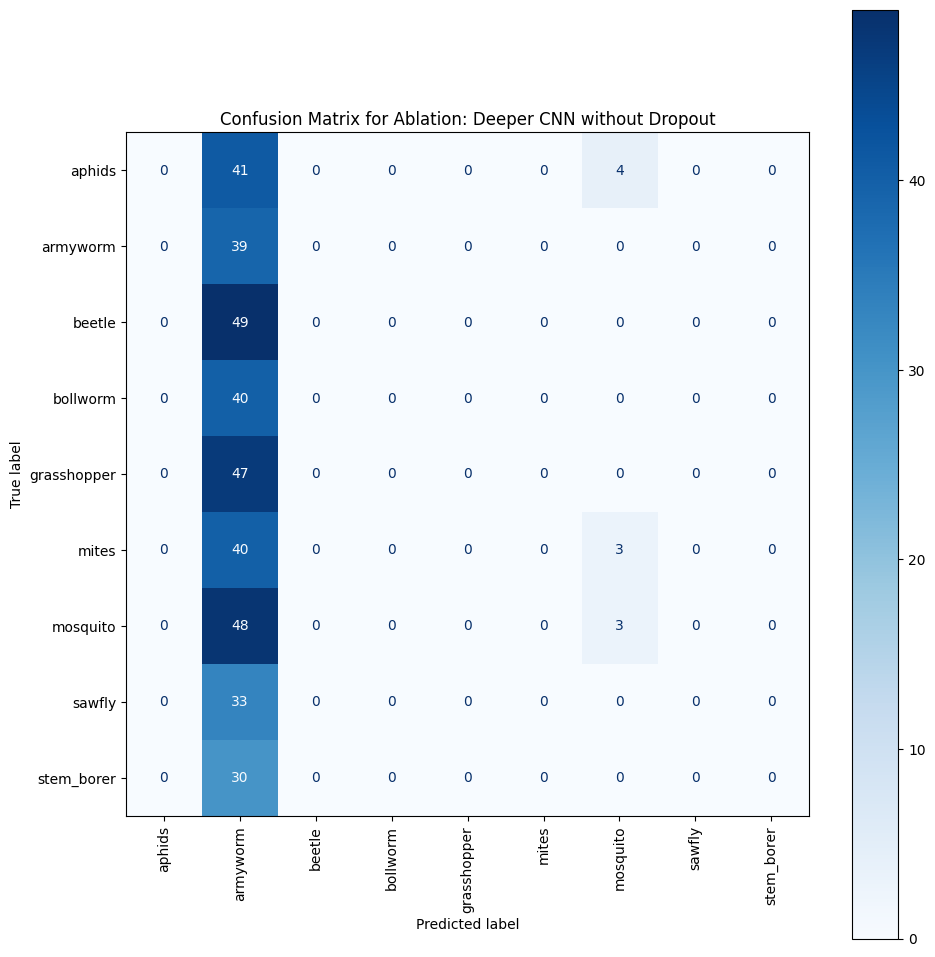

In [22]:
def build_deeper_cnn(input_shape=(224, 224, 3), num_classes=num_classes, optimizer_name='adam', use_dropout=True):
    # Removing L2 regularization to see if the model can learn initially
    # reg = regularizers.l2(1e-4) # Commented out as we are removing L2
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    if use_dropout:
        x = layers.Dropout(0.20)(x)

    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    if use_dropout:
        x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    if use_dropout:
        x = layers.Dropout(0.30)(x)

    x = layers.Conv2D(256, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation='relu')(x)
    if use_dropout:
        x = layers.Dropout(0.40)(x)
    x = layers.Dense(128, activation='relu')(x)
    if use_dropout:
        x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name=f'deeper_cnn_{optimizer_name}_dropout_{use_dropout}')

    # The optimizer is compiled below for the specific model to allow custom learning rates
    return model

deeper_no_dropout_model = build_deeper_cnn(optimizer_name='adam', use_dropout=False)
deeper_no_dropout_model.summary()

# Compile the model with a specific learning rate for this ablation study
deeper_no_dropout_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4), # Reduced learning rate for better convergence without L2
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
history_no_dropout = deeper_no_dropout_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_DEEPER,
    callbacks=callbacks_common,
    class_weight=class_weight,
    verbose=1
)
no_dropout_time = time.time() - start_time
print(f'Ablation model without Dropout training time: {no_dropout_time:.2f} seconds')

plot_history(history_no_dropout, 'Ablation: Deeper CNN without Dropout')
no_dropout_metrics, no_dropout_y_true, no_dropout_y_pred, no_dropout_y_prob = evaluate_model(deeper_no_dropout_model, test_ds, 'Ablation: Deeper CNN without Dropout')
no_dropout_metrics['training_time_seconds'] = no_dropout_time

## 12. Part B — Transfer Learning with MobileNetV2

MobileNetV2 is used because it is lighter than larger pre-trained CNNs and works well with 224 × 224 images. The original ImageNet classifier is removed and a new classifier is added for the insect classes.

Training strategy:

1. Feature extraction: freeze MobileNetV2 base and train only the new classifier.
2. Fine-tuning: unfreeze the last part of MobileNetV2 and train with a low learning rate.


In [23]:
def make_transfer_dataset(df, shuffle=False, augment=False):
    paths = df['path'].values
    labels = df['label'].map(class_to_index).values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)

    augmentation = keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10),
    ], name='transfer_augmentation')

    def load_for_transfer(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_image(image, channels=3, expand_animations=False)
        image.set_shape([None, None, 3])
        image = tf.image.resize(image, IMG_SIZE)
        image = tf.cast(image, tf.float32)
        if augment:
            image = augmentation(image, training=True)
        image = preprocess_input(image)
        label = tf.one_hot(label, depth=num_classes)
        return image, label

    ds = ds.map(load_for_transfer, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

transfer_train_ds = make_transfer_dataset(train_df, shuffle=True, augment=True)
transfer_val_ds = make_transfer_dataset(val_df, shuffle=False, augment=False)
transfer_test_ds = make_transfer_dataset(test_df, shuffle=False, augment=False)

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.20)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
transfer_model = keras.Model(inputs, outputs, name='mobilenetv2_transfer_learning')

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "mobilenetv2_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,113 (9.24 MB)

 Trainable params: 165,129 (645.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.5805 - loss: 1.2872 - val_accuracy: 0.8245 - val_loss: 0.5305 - learning_rate: 0.0010
Epoch 2/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 27s 489ms/step - accuracy: 0.8247 - loss: 0.5558 - val_accuracy: 0.9069 - val_loss: 0.3024 - learning_rate: 0.0010
Epoch 3/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 27s 492ms/step - accuracy: 0.8953 - loss: 0.3622 - val_accuracy: 0.9362 - val_loss: 0.2440 - learning_rate: 3.0000e-04
Epoch 4/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 27s 497ms/step - accuracy: 0.8970 - loss: 0.3370 - val_accuracy: 0.9362 - val_loss: 0.2135 - learning_rate: 3.0000e-04
Epoch 5/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 42s 509ms/step - accuracy: 0.9300 - loss: 0.2538 - val_accuracy: 0.9415 - val_loss: 0.2023 - learning_rate: 9.0000e-05
Epoch 6/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 27s 488ms/step - accuracy: 0.9249 - loss: 0.2623 - val_accuracy: 0.9415 - val_loss: 0.1978 - learning_rate: 9.0000e-05
Epoch 7/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 41s 484ms/step - accuracy: 0.93

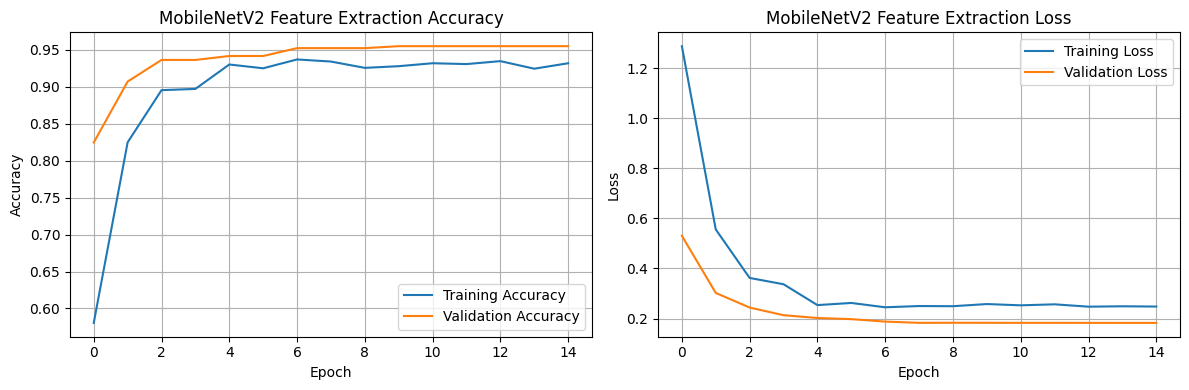


Evaluating MobileNetV2 Feature Extraction on test set...
MobileNetV2 Feature Extraction Test Loss: 0.4722
MobileNetV2 Feature Extraction Test Accuracy: 0.8515

Classification Report:
              precision    recall  f1-score   support

      aphids       0.94      0.64      0.76        45
    armyworm       0.76      0.90      0.82        39
      beetle       0.98      0.88      0.92        49
    bollworm       0.94      0.82      0.88        40
 grasshopper       0.80      1.00      0.89        47
       mites       0.95      0.91      0.93        43
    mosquito       1.00      0.98      0.99        51
      sawfly       0.62      0.76      0.68        33
  stem_borer       0.65      0.67      0.66        30

    accuracy                           0.85       377
   macro avg       0.85      0.84      0.84       377
weighted avg       0.87      0.85      0.85       377



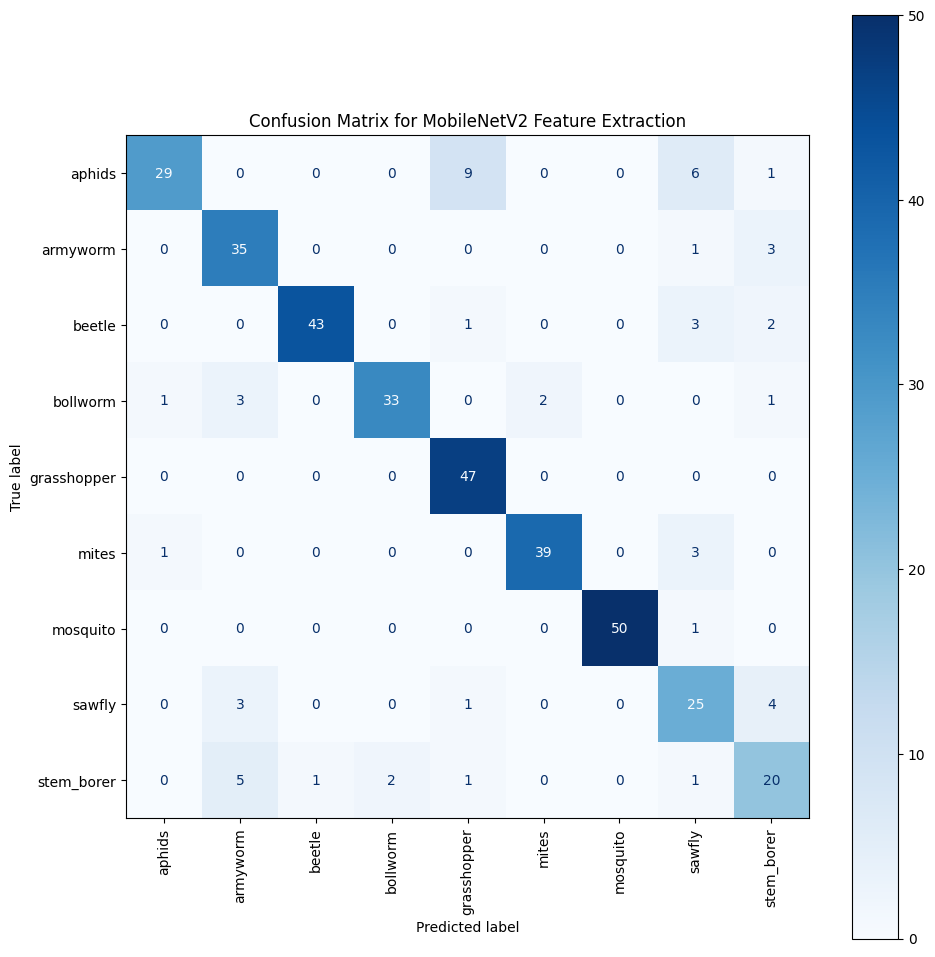

In [24]:
EPOCHS_TRANSFER = 15

start_time = time.time()
history_transfer = transfer_model.fit(
    transfer_train_ds,
    validation_data=transfer_val_ds,
    epochs=EPOCHS_TRANSFER,
    callbacks=callbacks_common,
    class_weight=class_weight,
    verbose=1
)
transfer_feature_time = time.time() - start_time
print(f'Transfer learning feature extraction time: {transfer_feature_time:.2f} seconds')

plot_history(history_transfer, 'MobileNetV2 Feature Extraction')
transfer_metrics, transfer_y_true, transfer_y_pred, transfer_y_prob = evaluate_model(transfer_model, transfer_test_ds, 'MobileNetV2 Feature Extraction')
transfer_metrics['training_time_seconds'] = transfer_feature_time

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 62s 762ms/step - accuracy: 0.6858 - loss: 0.9526 - val_accuracy: 0.8511 - val_loss: 0.4727 - learning_rate: 1.0000e-05
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 29s 531ms/step - accuracy: 0.7541 - loss: 0.7927 - val_accuracy: 0.8670 - val_loss: 0.4335 - learning_rate: 1.0000e-05
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 29s 527ms/step - accuracy: 0.7672 - loss: 0.7377 - val_accuracy: 0.8723 - val_loss: 0.4179 - learning_rate: 3.0000e-06
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 40s 513ms/step - accuracy: 0.7906 - loss: 0.7016 - val_accuracy: 0.8803 - val_loss: 0.4021 - learning_rate: 3.0000e-06
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 27s 491ms/step - accuracy: 0.7957 - loss: 0.6917 - val_accuracy: 0.8830 - val_loss: 0.3937 - learning_rate: 1.0000e-06
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 27s 484ms/step - accuracy: 0.8008 - loss: 0.6703 - val_accuracy: 0.8936 - val_loss: 0.3857 - learning_rate: 1.0000e-06
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 42s 509ms/step - acc

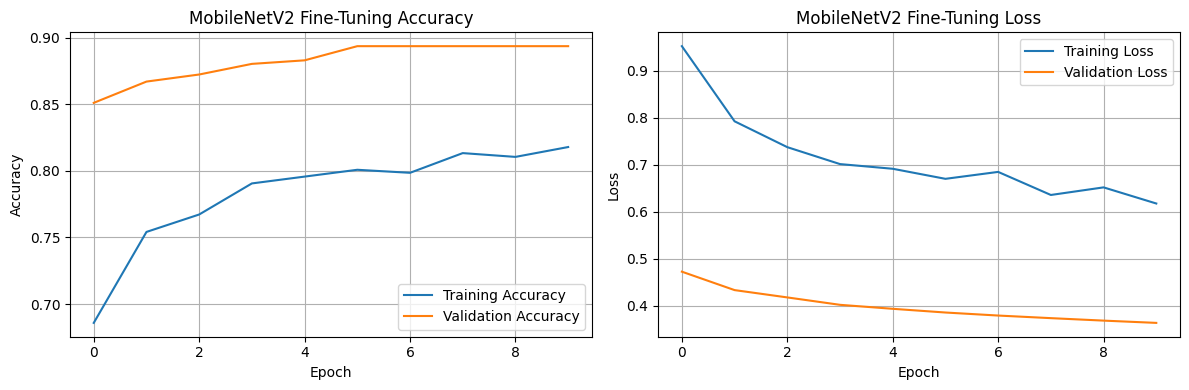


Evaluating MobileNetV2 Fine-Tuned on test set...
MobileNetV2 Fine-Tuned Test Loss: 0.4155
MobileNetV2 Fine-Tuned Test Accuracy: 0.8674

Classification Report:
              precision    recall  f1-score   support

      aphids       0.89      0.71      0.79        45
    armyworm       0.78      0.97      0.86        39
      beetle       0.96      0.92      0.94        49
    bollworm       0.91      0.78      0.84        40
 grasshopper       0.83      0.96      0.89        47
       mites       0.95      0.91      0.93        43
    mosquito       0.96      1.00      0.98        51
      sawfly       0.68      0.82      0.74        33
  stem_borer       0.83      0.63      0.72        30

    accuracy                           0.87       377
   macro avg       0.86      0.85      0.85       377
weighted avg       0.87      0.87      0.87       377



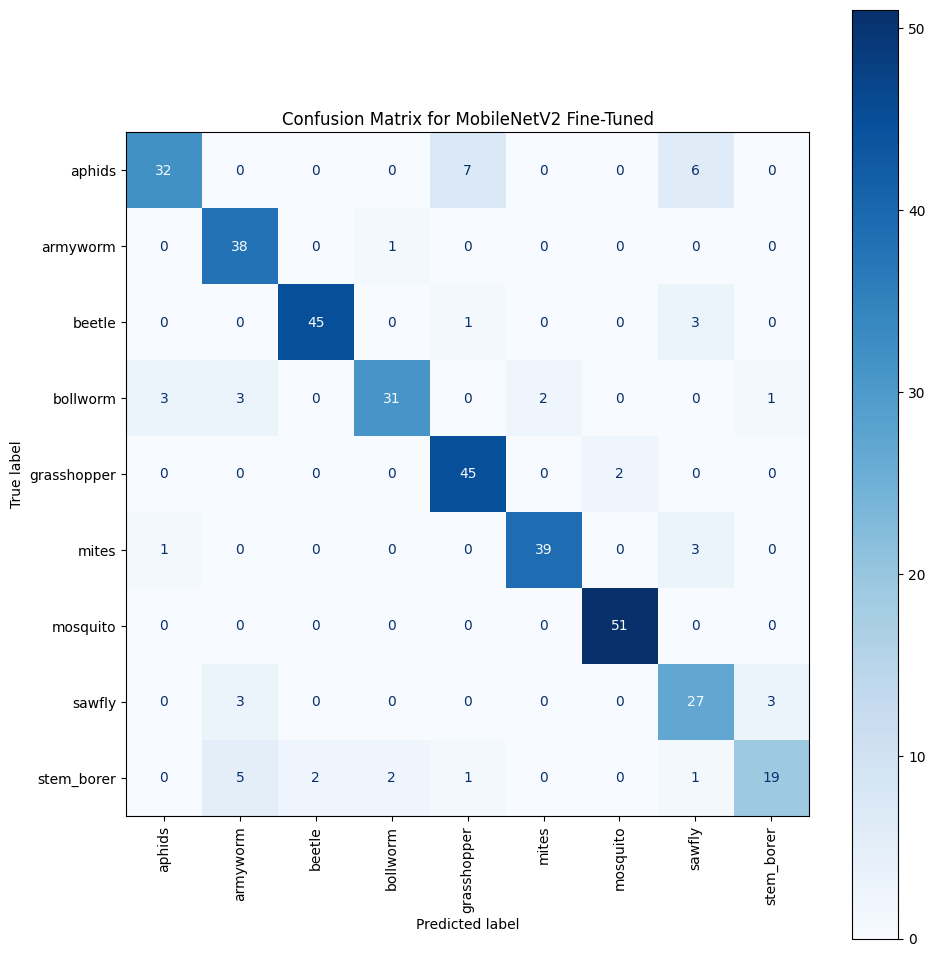

In [25]:
# Fine-tuning: unfreeze the last layers of the pre-trained base model.
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
history_finetune = transfer_model.fit(
    transfer_train_ds,
    validation_data=transfer_val_ds,
    epochs=10,
    callbacks=callbacks_common,
    class_weight=class_weight,
    verbose=1
)
finetune_time = time.time() - start_time
print(f'MobileNetV2 fine-tuning time: {finetune_time:.2f} seconds')

plot_history(history_finetune, 'MobileNetV2 Fine-Tuning')
finetune_metrics, finetune_y_true, finetune_y_pred, finetune_y_prob = evaluate_model(transfer_model, transfer_test_ds, 'MobileNetV2 Fine-Tuned')
finetune_metrics['training_time_seconds'] = transfer_feature_time + finetune_time

## Resources
<!-- Add comments about resources here, e.g., datasets, research papers, tools. -->

,model,accuracy,precision_weighted,recall_weighted,f1_weighted,training_time_seconds
0,Baseline CNN,0.9867,0.9875,0.9867,0.9868,638.8476
1,Deeper CNN with Adam,0.1379,0.0902,0.1379,0.0733,759.2116
2,Deeper CNN with SGD,0.1194,0.0142,0.1194,0.0255,753.2466
3,Ablation: Deeper CNN without Dropout,0.1114,0.0516,0.1114,0.0332,707.2342
4,MobileNetV2 Feature Extraction,0.8515,0.8666,0.8515,0.8524,497.3615
5,MobileNetV2 Fine-Tuned,0.8674,0.8749,0.8674,0.8659,876.7075


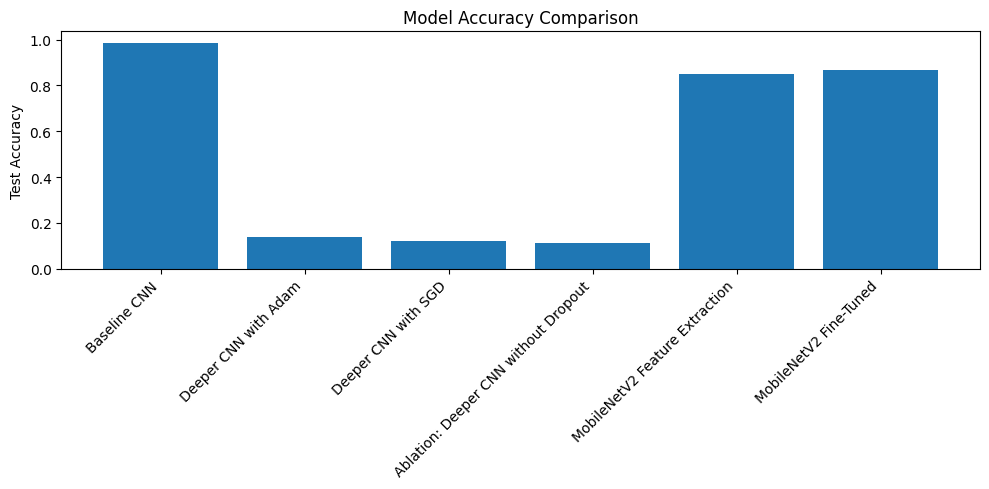

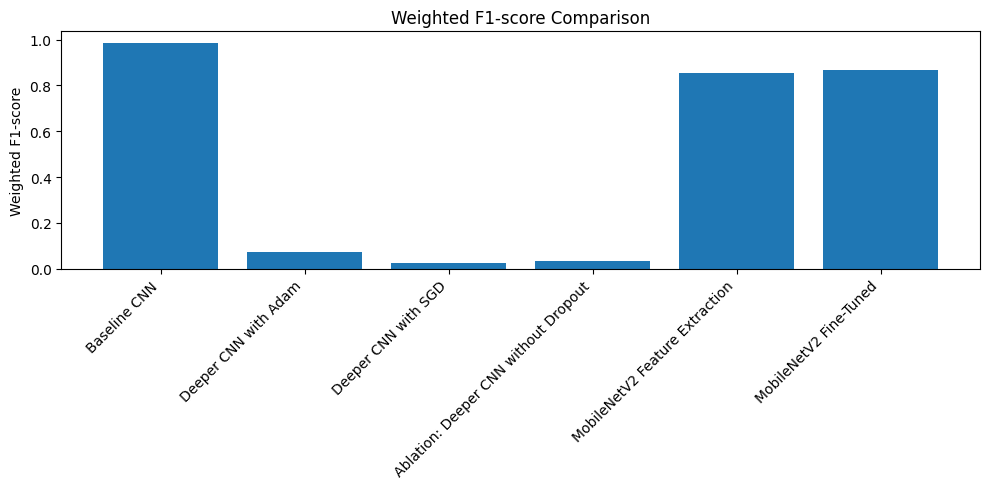

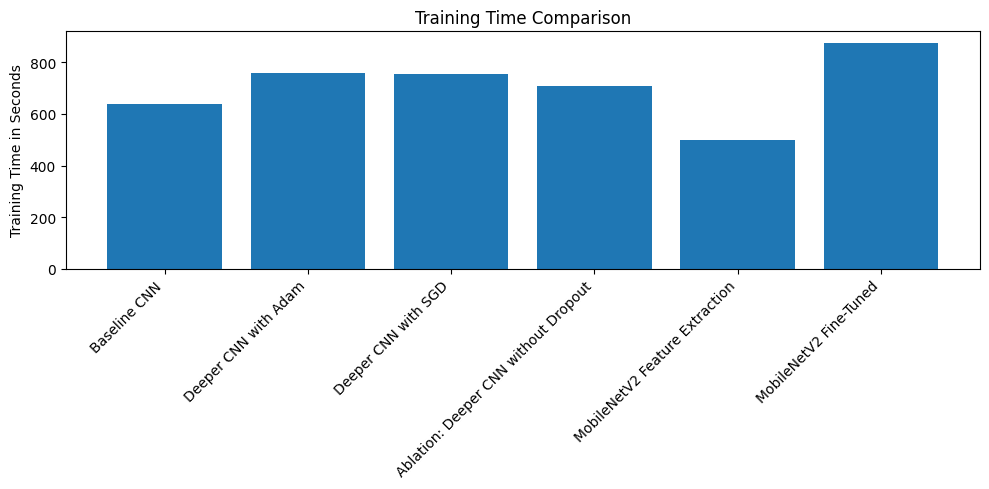

In [26]:
results = pd.DataFrame([
    baseline_metrics,
    deeper_adam_metrics,
    deeper_sgd_metrics,
    no_dropout_metrics,
    transfer_metrics,
    finetune_metrics
])

# Round numeric columns for clean display.
for col in results.columns:
    if col != 'model':
        results[col] = results[col].astype(float).round(4)

display(results)

plt.figure(figsize=(10, 5))
plt.bar(results['model'], results['accuracy'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Test Accuracy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results['model'], results['f1_weighted'])
plt.title('Weighted F1-score Comparison')
plt.ylabel('Weighted F1-score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results['model'], results['training_time_seconds'])
plt.title('Training Time Comparison')
plt.ylabel('Training Time in Seconds')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 14. Error Analysis

This section displays misclassified test images using the best model based on weighted F1-score.


Best model based on weighted F1-score: Baseline CNN
Number of misclassified test examples: 5


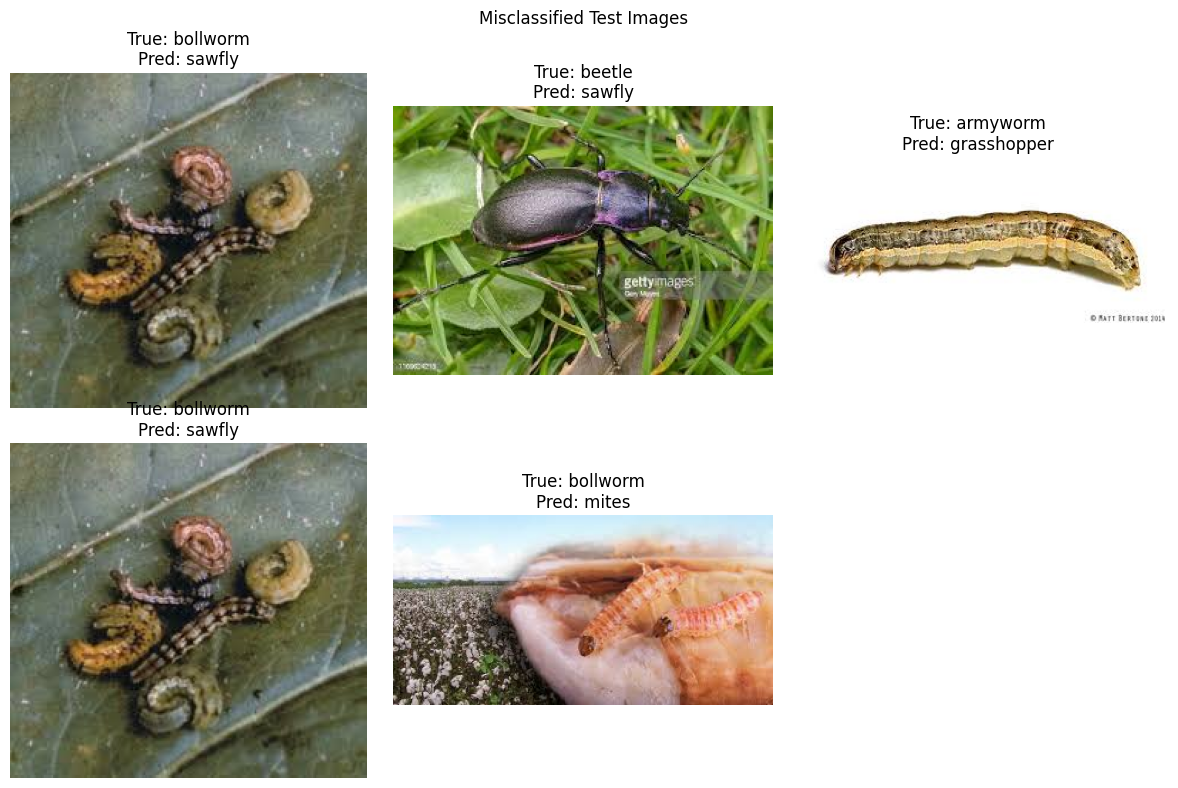

In [27]:
# Pick the best model from measured results.
best_model_name = results.sort_values('f1_weighted', ascending=False).iloc[0]['model']
print('Best model based on weighted F1-score:', best_model_name)

model_map = {
    'Baseline CNN': (baseline_model, test_ds, baseline_y_true, baseline_y_pred),
    'Deeper CNN with Adam': (deeper_adam_model, test_ds, deeper_adam_y_true, deeper_adam_y_pred),
    'Deeper CNN with SGD': (deeper_sgd_model, test_ds, deeper_sgd_y_true, deeper_sgd_y_pred),
    'Ablation: Deeper CNN without Dropout': (deeper_no_dropout_model, test_ds, no_dropout_y_true, no_dropout_y_pred),
    'MobileNetV2 Feature Extraction': (transfer_model, transfer_test_ds, transfer_y_true, transfer_y_pred),
    'MobileNetV2 Fine-Tuned': (transfer_model, transfer_test_ds, finetune_y_true, finetune_y_pred),
}

_, _, best_y_true, best_y_pred = model_map[best_model_name]
mis_idx = np.where(best_y_true != best_y_pred)[0]
print('Number of misclassified test examples:', len(mis_idx))

if len(mis_idx) > 0:
    show_count = min(6, len(mis_idx))
    chosen = mis_idx[:show_count]
    plt.figure(figsize=(12, 8))
    for plot_i, idx in enumerate(chosen):
        row = test_df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        true_label = index_to_class[int(best_y_true[idx])]
        pred_label = index_to_class[int(best_y_pred[idx])]
        plt.subplot(2, 3, plot_i + 1)
        plt.imshow(img)
        plt.title(f'True: {true_label}\nPred: {pred_label}')
        plt.axis('off')
    plt.suptitle('Misclassified Test Images')
    plt.tight_layout()
    plt.show()
else:
    print('No misclassified image found in the test set for this model.')

## 15. Notes for Report Writing

You can adapt these points in your final report:

- The dataset represents a multi-class insect image classification problem. The class names were taken from the folder names in the dataset.
- The dataset was inspected for unreadable/corrupted images, class distribution, image size, image mode, and exact duplicate images.
- Exact duplicate images were identified by comparing MD5 file hashes. Similar-looking insect photos were not treated as duplicates.
- Images were resized to 224 × 224 pixels and normalized for CNN models.
- Data augmentation was applied to the training set only to improve generalization.
- The baseline CNN used three convolutional blocks, three dense layers, and a softmax output layer.
- The deeper CNN used more convolutional layers, Batch Normalization, Dropout, L2 regularization, and Global Average Pooling.
- Adam and SGD were compared on the deeper CNN to observe differences in convergence and final accuracy.
- The ablation study removed Dropout to observe the effect of regularization.
- MobileNetV2 transfer learning was used for Part B by replacing the original classifier with a new classifier for the insect classes.
- Accuracy, precision, recall, weighted F1-score, confusion matrix, and prediction examples were used for evaluation.
